In [1]:
# DS602 Statistical Methods Lab 04
# Medical Insurance Cost - Statistical Analysis

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

PROJECT_DIR = Path(r"C:\Users\Hirav\Desktop\Medical-Insurance-Dashboard")


sys.path.insert(0, str(PROJECT_DIR))

print("Libraries imported successfully.")
print("Project folder:", PROJECT_DIR)

Libraries imported successfully.
Project folder: C:\Users\Hirav\Desktop\Medical-Insurance-Dashboard


In [2]:
from analysis import (
    load_data,
    descriptive_statistics,
    correlation_matrix,
    two_group_hypothesis_test,
    chi_square_test,
    one_way_anova,
    fit_ols_model,
    coefficient_table,
    calculate_vif,
    diagnostic_tests,
    residual_figure,
    qq_figure,
    predict_with_interval
)

print("analysis.py functions loaded successfully.")

analysis.py functions loaded successfully.


In [3]:
DATA_PATH = PROJECT_DIR / "data" / "insurance.csv"

df = load_data(DATA_PATH)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1338
Columns: 7


In [4]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [5]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (1338, 7)

Column Names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data Types:


age           int64
sex          string
bmi         float64
children      int64
smoker       string
region       string
charges     float64
dtype: object


Missing Values:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Duplicate Rows: 1


In [7]:
numeric_columns = ["age", "bmi", "children", "charges"]

desc_stats = descriptive_statistics(df)

display(desc_stats.round(4))

,Feature,Mean,Median,Std Dev,IQR,Skewness,Kurtosis
0,age,39.2070,39.000,14.0500,24.0000,0.0557,-1.2451
1,bmi,30.6634,30.400,6.0982,8.3975,0.2840,-0.0507
2,children,1.0949,1.000,1.2055,2.0000,0.9384,0.2025
3,charges,13270.4223,9382.033,12110.0112,11899.6254,1.5159,1.6063


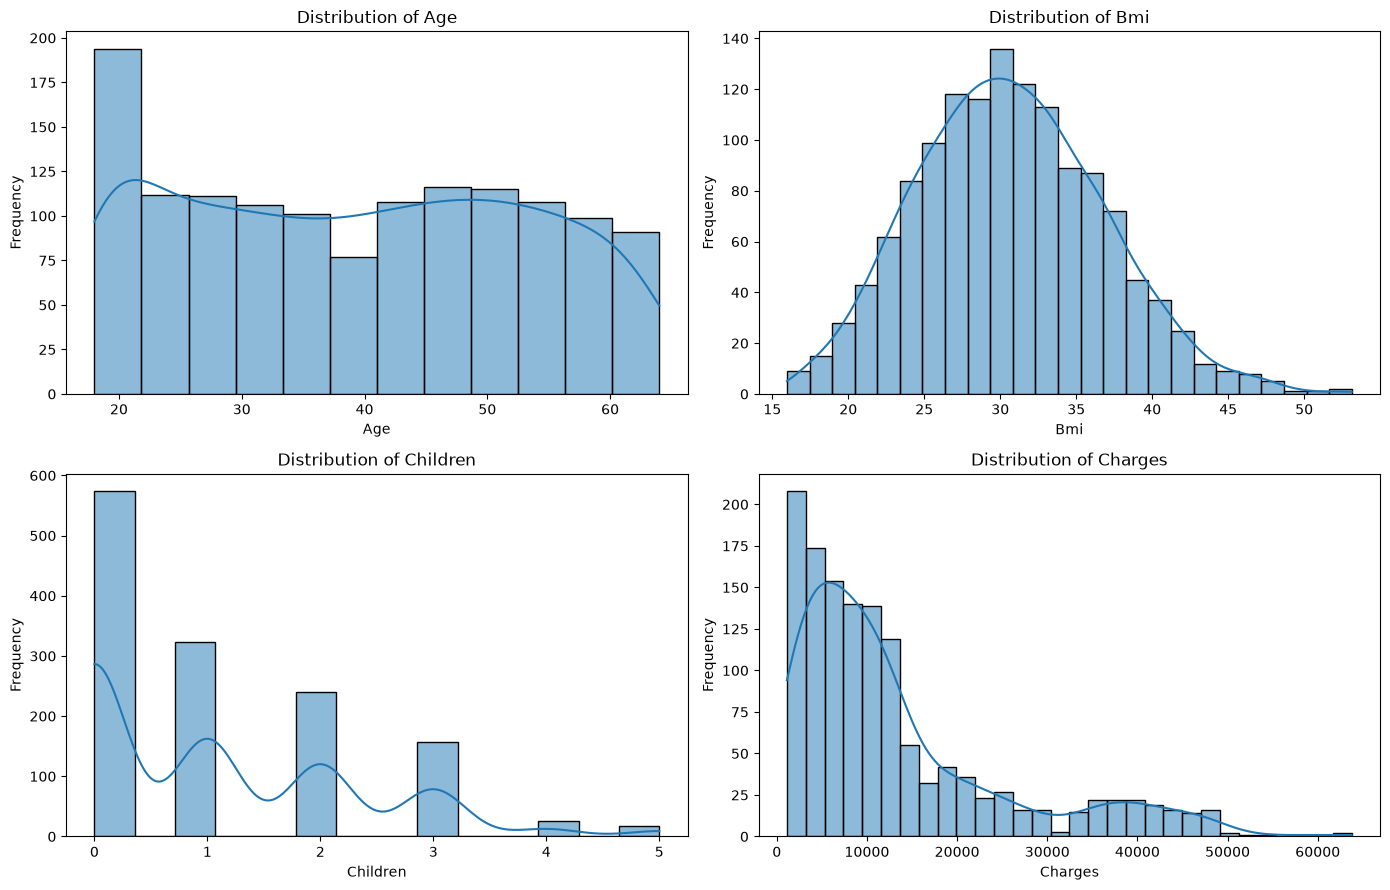

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.flat, ["age", "bmi", "children", "charges"]):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col.title()}")
    ax.set_xlabel(col.title())
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

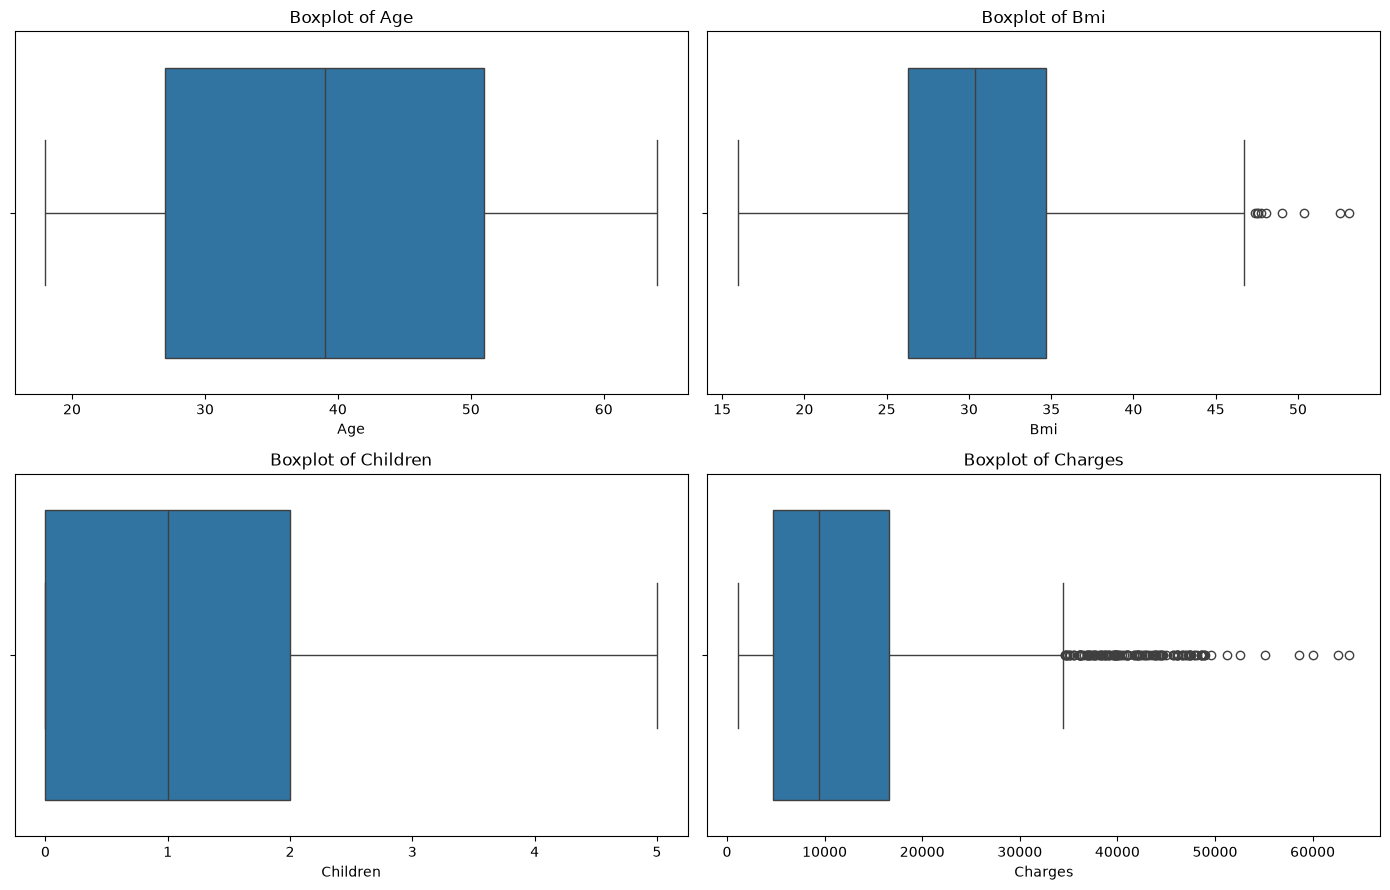

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.flat, ["age", "bmi", "children", "charges"]):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col.title()}")
    ax.set_xlabel(col.title())

plt.tight_layout()
plt.show()

In [10]:
corr = correlation_matrix(df)

display(corr.round(4))

,age,bmi,children,charges
age,1.0000,0.1093,0.0425,0.2990
bmi,0.1093,1.0000,0.0128,0.1983
children,0.0425,0.0128,1.0000,0.0680
charges,0.2990,0.1983,0.0680,1.0000


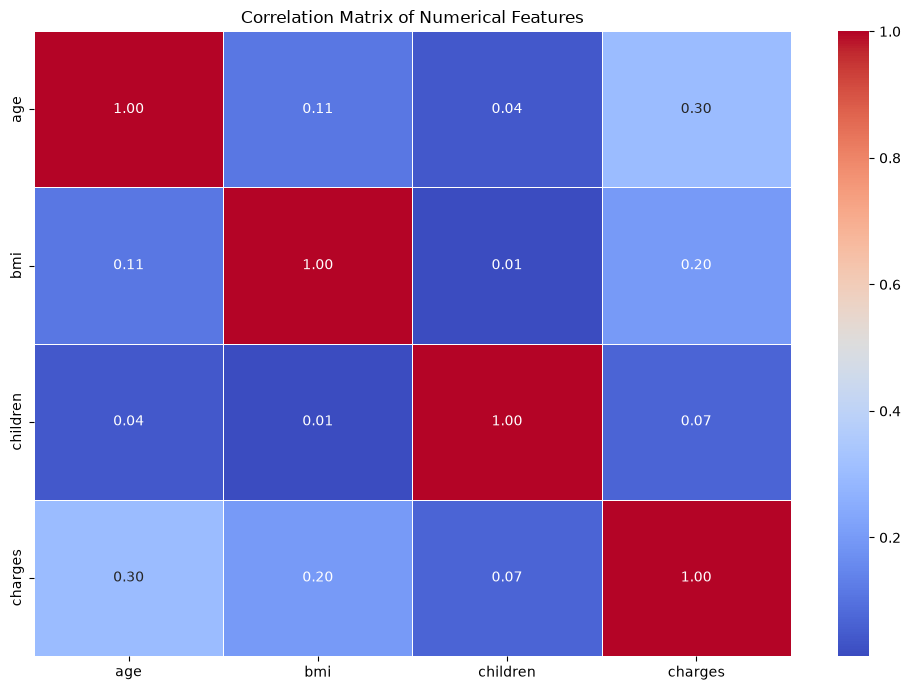

In [11]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [12]:
test1 = two_group_hypothesis_test(
    df,
    "smoker",
    "charges",
    "yes",
    "no"
)

display(pd.DataFrame([test1]).T.rename(columns={0: "Value"}))

,Value
mean_1,32050.231832
mean_2,8434.268298
n_1,274
n_2,1064
shapiro_1_stat,0.939552
shapiro_1_p,0.0
shapiro_2_stat,0.872864
shapiro_2_p,0.0
levene_stat,332.613516
levene_p,0.0


In [13]:
print("Hypothesis Test 1: Smoker Status vs Insurance Charges")
print(f"Smokers mean charges: {test1['mean_1']:.2f}")
print(f"Non-smokers mean charges: {test1['mean_2']:.2f}")
print(f"Mann-Whitney U statistic: {test1['test_stat']:.2f}")
print(f"p-value: {test1['p_value']:.4e}")

if test1["p_value"] < 0.05:
    print("Decision: Reject H0")
    print("Conclusion: Insurance charges differ significantly between smokers and non-smokers.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: No significant difference was detected.")

Hypothesis Test 1: Smoker Status vs Insurance Charges
Smokers mean charges: 32050.23
Non-smokers mean charges: 8434.27
Mann-Whitney U statistic: 284133.00
p-value: 5.2702e-130
Decision: Reject H0
Conclusion: Insurance charges differ significantly between smokers and non-smokers.


In [15]:
chi_result = chi_square_test(df, "smoker", "region")

print("Chi-Square Test: Smoker Status vs Region")
print(f"Chi-Square statistic: {chi_result['statistic']:.4f}")
print(f"Degrees of freedom: {chi_result['dof']}")
print(f"p-value: {chi_result['p_value']:.4f}")

print("\nObserved Frequencies:")
display(chi_result["observed"])

print("\nExpected Frequencies:")
display(chi_result["expected"])

if chi_result["p_value"] < 0.05:
    print("Decision: Reject H0")
    print("Conclusion: Smoker status and region are significantly associated.")
else:
    print("Decision: Fail to reject H0")
    print("Conclusion: No significant association was detected between smoker status and region.")

Chi-Square Test: Smoker Status vs Region
Chi-Square statistic: 7.3435
Degrees of freedom: 3
p-value: 0.0617

Observed Frequencies:


region,northeast,northwest,southeast,southwest
smoker,,,,
no,257,267,273,267
yes,67,58,91,58



Expected Frequencies:


region,northeast,northwest,southeast,southwest
smoker,,,,
no,257.650224,258.445441,289.458894,258.445441
yes,66.349776,66.554559,74.541106,66.554559


Decision: Fail to reject H0
Conclusion: No significant association was detected between smoker status and region.


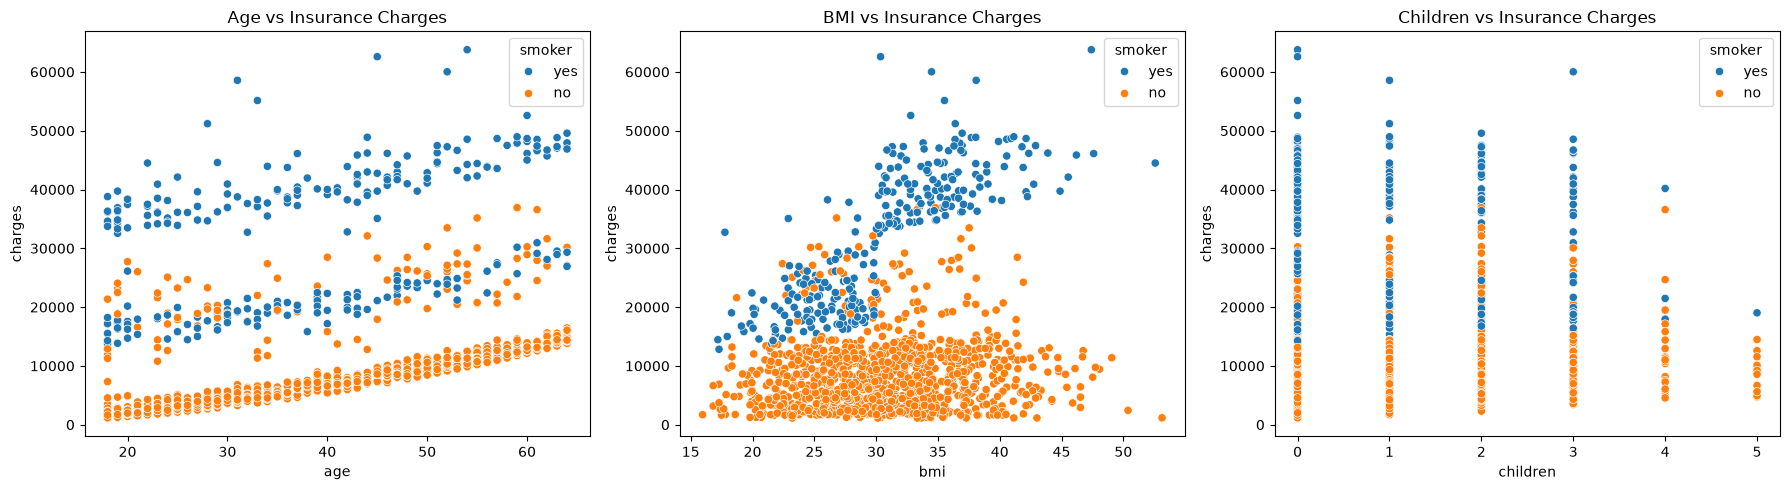

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="age", y="charges", hue="smoker", ax=axes[0])
axes[0].set_title("Age vs Insurance Charges")

sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", ax=axes[1])
axes[1].set_title("BMI vs Insurance Charges")

sns.scatterplot(data=df, x="children", y="charges", hue="smoker", ax=axes[2])
axes[2].set_title("Children vs Insurance Charges")

plt.tight_layout()
plt.show()

In [18]:
model, X, y = fit_ols_model(df)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:23:45   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

In [19]:
coef_table = coefficient_table(model)

display(coef_table.round(4))

,Coefficient,P-value,CI Lower 95%,CI Upper 95%
const,-11938.5386,0.0000,-13876.3934,-10000.6837
age,256.8564,0.0000,233.5138,280.1989
bmi,339.1935,0.0000,283.0884,395.2985
children,475.5005,0.0006,205.1633,745.8378
sex_male,-131.3144,0.6933,-784.4703,521.8416
smoker_yes,23848.5345,0.0000,23038.0307,24659.0384
region_northwest,-352.9639,0.4588,-1287.2982,581.3704
region_southeast,-1035.0220,0.0308,-1974.0968,-95.9473
region_southwest,-960.0510,0.0448,-1897.6364,-22.4656


In [20]:
vif_table = calculate_vif(df)

display(vif_table.round(4))

,Feature,VIF
0,age,1.0138
1,bmi,1.0122
2,children,1.0019


In [22]:
diagnostics = diagnostic_tests(model, X)

print("Jarque-Bera Test")
print(f"Statistic: {diagnostics['jb_stat']:.4f}")
print(f"p-value: {diagnostics['jb_p']:.4e}")

print("\nBreusch-Pagan Test")
print(f"LM Statistic: {diagnostics['bp_lm_stat']:.4f}")
print(f"LM p-value: {diagnostics['bp_lm_p']:.4e}")
print(f"F Statistic: {diagnostics['bp_f_stat']:.4f}")
print(f"F p-value: {diagnostics['bp_f_p']:.4e}")

Jarque-Bera Test
Statistic: 718.8873
p-value: 7.8635e-157

Breusch-Pagan Test
LM Statistic: 121.7436
LM p-value: 1.4467e-22
F Statistic: 16.6286
F p-value: 1.1456e-23


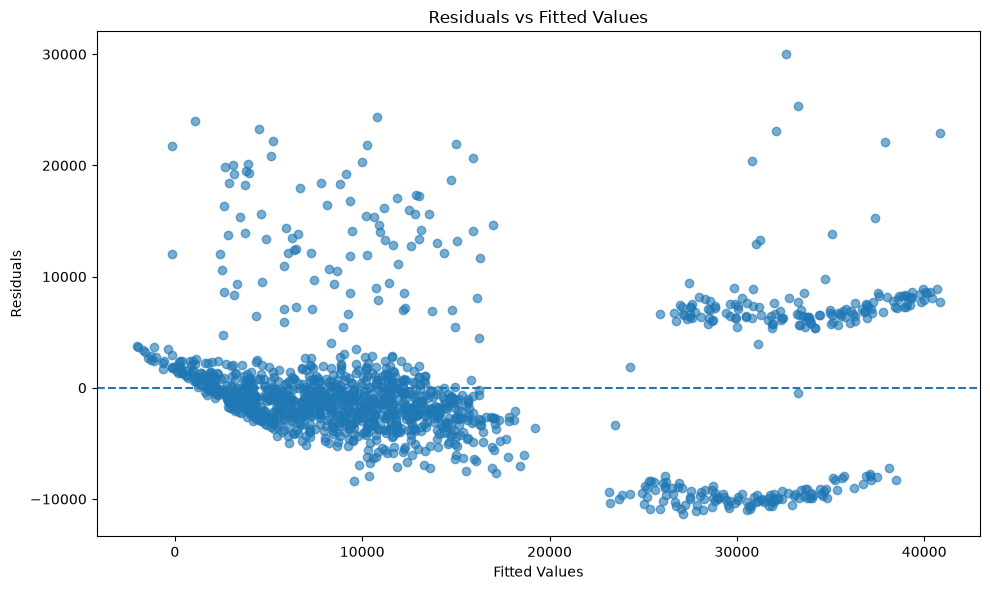

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(model.fittedvalues, model.resid, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.tight_layout()
plt.show()

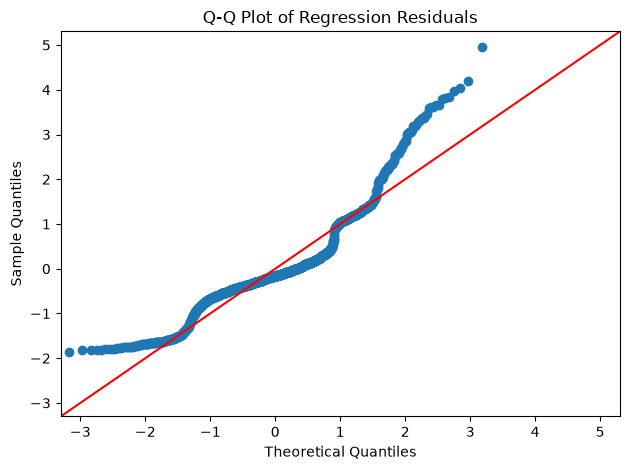

In [25]:
sm.qqplot(model.resid, line="45", fit=True)
plt.title("Q-Q Plot of Regression Residuals")
plt.tight_layout()
plt.show()

In [26]:
prediction = predict_with_interval(
    model,
    age=40,
    bmi=30,
    children=2,
    sex="male",
    smoker="no",
    region="southeast"
)

display(prediction.round(2))

mean              9462.52
mean_se            406.82
mean_ci_lower     8664.44
mean_ci_upper    10260.61
obs_ci_lower     -2456.56
obs_ci_upper     21381.60
Name: 0, dtype: float64

In [27]:
print("FINAL STATISTICAL FINDINGS")
print("=" * 60)

print("\n1. DATASET")
print(f"Observations: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n2. DESCRIPTIVE STATISTICS")
print(f"Mean insurance charges: {df['charges'].mean():.2f}")
print(f"Median insurance charges: {df['charges'].median():.2f}")
print(f"Charges skewness: {df['charges'].skew():.4f}")
print(f"Charges kurtosis: {df['charges'].kurtosis():.4f}")

print("\n3. HYPOTHESIS TEST 1")
print("Comparison: Smoker vs Non-Smoker Insurance Charges")
print(f"Mann-Whitney U p-value: {test1['p_value']:.4e}")
print("Decision: Reject H0")
print("Conclusion: Insurance charges differ significantly between smokers and non-smokers.")

print("\n4. HYPOTHESIS TEST 2")
print("Test: Chi-Square Test of Independence")
print(f"Chi-Square statistic: {chi_result['statistic']:.4f}")
print(f"p-value: {chi_result['p_value']:.4f}")
print("Decision: Fail to reject H0")
print("Conclusion: No significant association was detected between smoker status and region.")

print("\n5. MULTIPLE LINEAR REGRESSION")
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
print(f"F-statistic: {model.fvalue:.4f}")
print(f"F-test p-value: {model.f_pvalue:.4e}")
print("Conclusion: The overall regression model is statistically significant.")

print("\n6. MULTICOLLINEARITY")
print("All continuous predictor VIF values are close to 1,")
print("indicating no serious multicollinearity.")

print("\n7. REGRESSION DIAGNOSTICS")
print(f"Jarque-Bera p-value: {diagnostics['jb_p']:.4e}")
print(f"Breusch-Pagan p-value: {diagnostics['bp_lm_p']:.4e}")
print("Residual normality is rejected based on the Jarque-Bera test.")
print("Heteroscedasticity is indicated by the Breusch-Pagan test.")

print("\n8. EXAMPLE PREDICTION")
print(f"Predicted charge: {prediction['mean']:.2f}")
print(f"95% Prediction Interval: {prediction['obs_ci_lower']:.2f} to {prediction['obs_ci_upper']:.2f}")

print("\nOVERALL CONCLUSION")
print("Smoking status is a major factor associated with medical insurance charges.")
print("Age, BMI, children and smoking status contribute to the regression model.")
print("The model explains approximately 75% of the variation in insurance charges.")
print("Diagnostic tests indicate non-normal residuals and heteroscedasticity.")

FINAL STATISTICAL FINDINGS

1. DATASET
Observations: 1338
Variables: 7
Missing values: 0
Duplicate rows: 1

2. DESCRIPTIVE STATISTICS
Mean insurance charges: 13270.42
Median insurance charges: 9382.03
Charges skewness: 1.5159
Charges kurtosis: 1.6063

3. HYPOTHESIS TEST 1
Comparison: Smoker vs Non-Smoker Insurance Charges
Mann-Whitney U p-value: 5.2702e-130
Decision: Reject H0
Conclusion: Insurance charges differ significantly between smokers and non-smokers.

4. HYPOTHESIS TEST 2
Test: Chi-Square Test of Independence
Chi-Square statistic: 7.3435
p-value: 0.0617
Decision: Fail to reject H0
Conclusion: No significant association was detected between smoker status and region.

5. MULTIPLE LINEAR REGRESSION
R-squared: 0.7509
Adjusted R-squared: 0.7494
F-statistic: 500.8107
F-test p-value: 0.0000e+00
Conclusion: The overall regression model is statistically significant.

6. MULTICOLLINEARITY
All continuous predictor VIF values are close to 1,
indicating no serious multicollinearity.

7. RE